In [52]:
# Cell 1: Import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import gradio as gr


In [ ]:
# Cell 2: Load dataset mentah dari file Excel

df = pd.read_excel ("jumlah-rombongan-belajar-menurut-tingkat-tiap-propinsi-indonesia-sd-2024.xlsx")

df = read()


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Provinsi,Tingkat - I,Tingkat - II,Tingkat - III,Tingkat - IV,Tingkat - V,Tingkat - VI,Jumlah,Status
2,Prov. D.K.I. Jakarta,2965,2931,2840,2827,3093,3309,17965,Negeri
3,Prov. Jawa Barat,24887,24722,24720,23396,23863,23701,145289,Negeri
4,Prov. Jawa Tengah,19112,18925,19016,18736,18786,18830,113405,Negeri


In [54]:
# Cell 3: Membersihkan header dan memilih kolom penting

# Baris ke-1 (index 1) berisi header sebenarnya
new_header = df_raw.iloc[1]   # baris header: Provinsi, Tingkat - I, ..., Status

# Data mulai dari baris ke-2 (index 2)
df = df_raw.iloc[2:].copy()
df.columns = new_header

# Reset index
df = df.reset_index(drop=True)

print("✅ Data setelah perbaikan header:")
display(df.head())
print(df.columns)


✅ Data setelah perbaikan header:


1,Provinsi,Tingkat - I,Tingkat - II,Tingkat - III,Tingkat - IV,Tingkat - V,Tingkat - VI,Jumlah,Status
0,Prov. D.K.I. Jakarta,2965,2931,2840,2827,3093,3309,17965,Negeri
1,Prov. Jawa Barat,24887,24722,24720,23396,23863,23701,145289,Negeri
2,Prov. Jawa Tengah,19112,18925,19016,18736,18786,18830,113405,Negeri
3,Prov. D.I. Yogyakarta,1624,1622,1636,1619,1635,1642,9778,Negeri
4,Prov. Jawa Timur,19531,19247,19258,19118,19207,19459,115820,Negeri


Index(['Provinsi', 'Tingkat - I', 'Tingkat - II', 'Tingkat - III',
       'Tingkat - IV', 'Tingkat - V', 'Tingkat - VI', 'Jumlah', 'Status'],
      dtype='object', name=1)


In [55]:
# Cell 4: Rename kolom agar lebih mudah diolah

df = df.rename(columns={
    'Provinsi': 'Provinsi',
    'Tingkat - I': 'Tingkat_1',
    'Tingkat - II': 'Tingkat_2',
    'Tingkat - III': 'Tingkat_3',
    'Tingkat - IV': 'Tingkat_4',
    'Tingkat - V': 'Tingkat_5',
    'Tingkat - VI': 'Tingkat_6',
    'Jumlah': 'Jumlah',
    'Status': 'Status'
})

# Pilih hanya kolom yang kita perlukan
kolom_pakai = ['Provinsi', 'Tingkat_1', 'Tingkat_2', 'Tingkat_3',
               'Tingkat_4', 'Tingkat_5', 'Tingkat_6', 'Jumlah']

df = df[kolom_pakai]

# Konversi kolom numerik ke tipe int/float
num_cols = ['Tingkat_1', 'Tingkat_2', 'Tingkat_3',
            'Tingkat_4', 'Tingkat_5', 'Tingkat_6', 'Jumlah']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("✅ Data setelah rename kolom dan konversi numerik:")
display(df.head())
print(df.info())


✅ Data setelah rename kolom dan konversi numerik:


1,Provinsi,Tingkat_1,Tingkat_2,Tingkat_3,Tingkat_4,Tingkat_5,Tingkat_6,Jumlah
0,Prov. D.K.I. Jakarta,2965.0,2931.0,2840.0,2827.0,3093.0,3309.0,17965.0
1,Prov. Jawa Barat,24887.0,24722.0,24720.0,23396.0,23863.0,23701.0,145289.0
2,Prov. Jawa Tengah,19112.0,18925.0,19016.0,18736.0,18786.0,18830.0,113405.0
3,Prov. D.I. Yogyakarta,1624.0,1622.0,1636.0,1619.0,1635.0,1642.0,9778.0
4,Prov. Jawa Timur,19531.0,19247.0,19258.0,19118.0,19207.0,19459.0,115820.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Provinsi   80 non-null     object 
 1   Tingkat_1  78 non-null     float64
 2   Tingkat_2  78 non-null     float64
 3   Tingkat_3  78 non-null     float64
 4   Tingkat_4  78 non-null     float64
 5   Tingkat_5  78 non-null     float64
 6   Tingkat_6  78 non-null     float64
 7   Jumlah     78 non-null     float64
dtypes: float64(7), object(1)
memory usage: 5.3+ KB
None


In [56]:
# Cell 5: Cek dan tangani missing value

print("Jumlah missing value per kolom:")
print(df.isnull().sum())

# Jika ada NaN di kolom numerik, isi dengan median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print("\n✅ Setelah imputasi missing value:")
print(df.isnull().sum())


Jumlah missing value per kolom:
1
Provinsi     2
Tingkat_1    4
Tingkat_2    4
Tingkat_3    4
Tingkat_4    4
Tingkat_5    4
Tingkat_6    4
Jumlah       4
dtype: int64

✅ Setelah imputasi missing value:
1
Provinsi     2
Tingkat_1    0
Tingkat_2    0
Tingkat_3    0
Tingkat_4    0
Tingkat_5    0
Tingkat_6    0
Jumlah       0
dtype: int64


Statistik deskriptif:


1,Tingkat_1,Tingkat_2,Tingkat_3,Tingkat_4,Tingkat_5,Tingkat_6,Jumlah
count,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000
mean,2437.646341,2428.621951,2421.548780,2348.109756,2358.439024,2353.756098,14348.170732
std,4188.407838,4152.892036,4156.959358,4032.011243,4072.700698,4082.347417,24682.785636
min,48.000000,47.000000,45.000000,41.000000,39.000000,35.000000,261.000000
25%,405.750000,413.500000,407.750000,385.000000,377.000000,346.500000,2358.750000
50%,950.500000,960.000000,961.500000,943.000000,934.500000,937.000000,5687.500000
75%,2762.750000,2747.000000,2785.000000,2714.750000,2667.500000,2660.500000,16319.250000
max,24887.000000,24722.000000,24720.000000,23396.000000,23863.000000,23701.000000,145289.000000


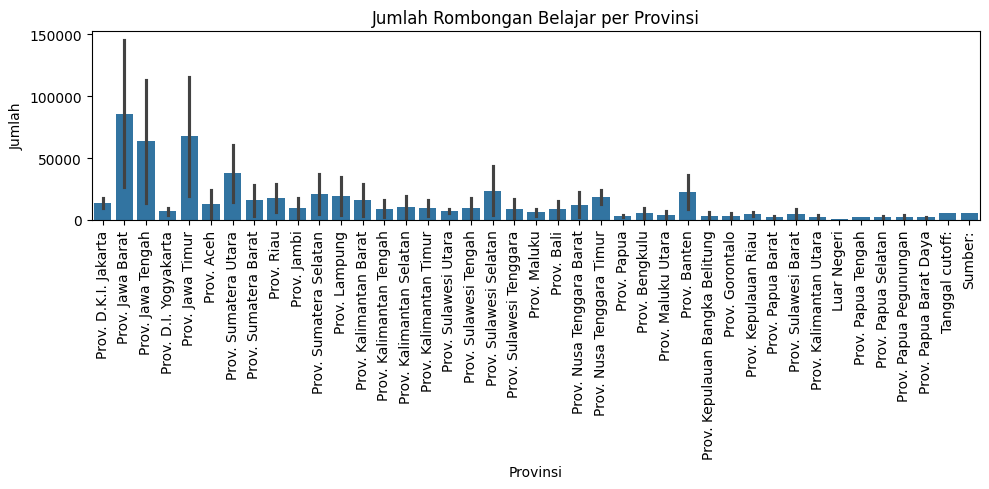

In [57]:
# Cell 6: Statistik deskriptif dan plot sederhana

print("Statistik deskriptif:")
display(df[num_cols].describe())

plt.figure(figsize=(10, 5))
sns.barplot(x='Provinsi', y='Jumlah', data=df)
plt.xticks(rotation=90)
plt.title('Jumlah Rombongan Belajar per Provinsi')
plt.tight_layout()
plt.show()


In [58]:
# Cell 7: Menentukan fitur (X) dan target (y) + Train-Test Split

feature_cols = ['Tingkat_1', 'Tingkat_2', 'Tingkat_3',
                'Tingkat_4', 'Tingkat_5', 'Tingkat_6']

X = df[feature_cols]
y = df['Jumlah']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Ukuran data:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


Ukuran data:
X_train: (65, 6)
X_test : (17, 6)


In [59]:
# Cell 8: Training model Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("✅ Model Random Forest berhasil dilatih.")


✅ Model Random Forest berhasil dilatih.


📊 Hasil Evaluasi Model
MAE  : 865.63
RMSE : 2108.56
R^2  : 0.9941


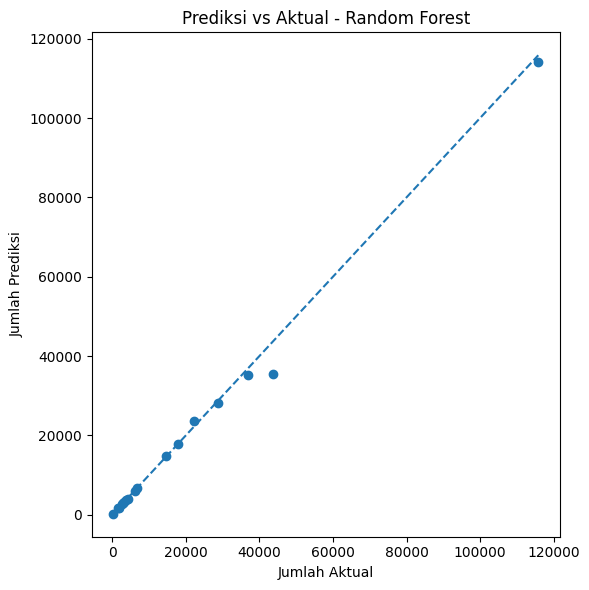

In [60]:
# Cell 9: Evaluasi model

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

# versi sklearn kamu belum mendukung squared=False, jadi pakai cara manual
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("📊 Hasil Evaluasi Model")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R^2  : {r2:.4f}")

# Plot Prediksi vs Aktual
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Jumlah Aktual")
plt.ylabel("Jumlah Prediksi")
plt.title("Prediksi vs Aktual - Random Forest")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.tight_layout()
plt.show()


In [61]:
# Cell 10: Menyimpan model dan daftar kolom fitur

joblib.dump(rf_model, "model_rf_rombel.pkl")
print("✅ Model disimpan sebagai model_rf_rombel.pkl")

# Simpan juga daftar nama fitur (kalau nanti mau dipakai ulang)
joblib.dump(feature_cols, "feature_cols.pkl")
print("✅ Daftar fitur disimpan sebagai feature_cols.pkl")


✅ Model disimpan sebagai model_rf_rombel.pkl
✅ Daftar fitur disimpan sebagai feature_cols.pkl


In [62]:
# Cell 11: Gradio interface untuk prediksi Rombongan Belajar

# Load ulang model & fitur (jaga-jaga kalau cell dijalankan terpisah)
rf_model = joblib.load("model_rf_rombel.pkl")
feature_cols = joblib.load("feature_cols.pkl")

def prediksi_rombel(t1, t2, t3, t4, t5, t6):
    """
    Fungsi untuk Gradio: menerima input 6 angka (rombel per tingkat),
    lalu mengembalikan prediksi total rombel.
    """
    data_input = pd.DataFrame([{
        'Tingkat_1': t1,
        'Tingkat_2': t2,
        'Tingkat_3': t3,
        'Tingkat_4': t4,
        'Tingkat_5': t5,
        'Tingkat_6': t6
    }])
    
    pred = rf_model.predict(data_input)[0]
    return f"Perkiraan total rombongan belajar: {pred:.0f} rombel"

# Definisi interface Gradio
inputs = [
    gr.Number(label="Rombel Tingkat I"),
    gr.Number(label="Rombel Tingkat II"),
    gr.Number(label="Rombel Tingkat III"),
    gr.Number(label="Rombel Tingkat IV"),
    gr.Number(label="Rombel Tingkat V"),
    gr.Number(label="Rombel Tingkat VI"),
]

output = gr.Textbox(label="Hasil Prediksi Total Rombel")

demo = gr.Interface(
    fn=prediksi_rombel,
    inputs=inputs,
    outputs=output,
    title="Prediksi Jumlah Rombongan Belajar SD",
    description="Masukkan jumlah rombel per tingkat, sistem akan memprediksi total rombongan belajar."
)

demo.launch()


* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.
